# 10 — Man AHL-style multi-speed trend following

## 🧭 tl;dr

Man AHL publicly discusses diversified trend following, multiple trading speeds, volatility scaling, and crisis behavior. This notebook tests fast, medium, slow, and blended time-series momentum on liquid ETF proxies. It is a transparent educational approximation—not Man AHL's futures, FX-forward, execution, or proprietary signal stack.

> Educational research only. This notebook is not investment advice.

<div style="border-left: 5px solid #2563EB; padding: 0.85em 1em; margin: 1em 0 1.4em; background: #F8FAFC; border-radius: 8px;">
<strong>🧭 Reader guide</strong><br>
Start with the assumptions, then follow the data and rule definitions. The tables and charts report the formal test period. Finish with <strong>What went well / what went wrong</strong> — that is where the research judgment and limitations are made explicit.
</div>


## 🧭 Context & methods

Time-series momentum asks whether each market has been rising or falling on its own. A positive trailing return creates a long position; a negative trailing return creates a short position. A managed-futures-style portfolio applies that rule across unrelated markets and scales exposure so one volatile market does not dominate.

### Key assumptions

- `SPY`, `TLT`, `GLD`, `DBC`, `EFA`, and `EEM` are ETF proxies for equity indices, government bonds, gold, commodities, developed-market equities, and emerging-market equities.
- Fast, medium, and slow lookbacks are 21, 63, and 126 trading days. The multi-speed blend averages 21, 63, 126, and 252-day models.
- Signals are decided monthly from prior data, volatility-scaled to a 10% target, and executed one bar later. Costs are 10 bps per unit of absolute weight turnover.
- Shorts are modeled as frictionless ETF short exposure. Borrow costs, financing, margin, futures rolls, and leverage are not included.

In [1]:
from pathlib import Path
import sys
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd

from src.data import load_price_panel, make_demo_ohlcv
from src.backtest import split_time_series
from src.fund_strategies import volatility_scaled_time_series_momentum_weights
from src.portfolio import run_portfolio_backtest
from src.research import comparison_table, metrics_for_period

# Consistent visual language across the research library.
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "figure.dpi": 120,
    "savefig.dpi": 160,
    "axes.facecolor": "#F8FAFC",
    "axes.edgecolor": "#CBD5E1",
    "axes.grid": True,
    "grid.color": "#CBD5E1",
    "grid.alpha": 0.35,
    "axes.titleweight": "bold",
    "axes.titlesize": 14,
    "axes.labelcolor": "#334155",
    "xtick.color": "#475569",
    "ytick.color": "#475569",
    "legend.frameon": False,
    "figure.autolayout": True,
})


## 📦 Data

The common sample begins in 2006. The demo fallback is deterministic, so the notebook can still teach the workflow without a network connection.

In [2]:
USE_DEMO_DATA = False
TRANSACTION_COST_BPS = 10
TICKERS = ['SPY', 'TLT', 'GLD', 'DBC', 'EFA', 'EEM']

if USE_DEMO_DATA:
    close = pd.concat([make_demo_ohlcv(periods=5_000, seed=i + 30, start='2006-01-01')['close'].rename(t) for i, t in enumerate(TICKERS)], axis=1)
else:
    try:
        close = load_price_panel(TICKERS, '2006-01-01', '2026-01-01')
    except Exception as exc:
        print(f'Live download unavailable ({type(exc).__name__}: {exc}); using deterministic demo data.')
        close = pd.concat([make_demo_ohlcv(periods=5_000, seed=i + 30, start='2006-01-01')['close'].rename(t) for i, t in enumerate(TICKERS)], axis=1)

splits = split_time_series(close, train_fraction=0.60, validation_fraction=0.20)
benchmark_returns = close['SPY'].pct_change().fillna(0.0)
print(f'Data: {close.index.min().date()} through {close.index.max().date()} ({len(close):,} common trading days)')

Data: 2006-02-06 through 2025-12-31 (5,008 common trading days)


## 📚 Public research and strategy translation

- [Man AHL: The Need for Speed in Trend-Following](https://www.man.com/insights/need-for-speed-trend-following) discusses fast and slow moving-average trend models, multi-asset diversification, volatility scaling, and the trade-off between speed and costs.
- [Man AHL: Trend Following — Equity and Bond Crisis Alpha](https://www.man.com/insights/trend-following-equity-bond-crisis-alpha) motivates checking performance in equity and bond stress.

The notebook uses simple trailing-return signs instead of proprietary double-exponential moving averages and uses ETFs instead of futures and FX forwards.

In [3]:
lookbacks = {'Fast trend (21d)': 21, 'Medium trend (63d)': 63, 'Slow trend (126d)': 126, 'Very slow trend (252d)': 252}
weights = {
    name: volatility_scaled_time_series_momentum_weights(
        close, lookback=lookback, volatility_lookback=63, target_volatility=0.10
    )
    for name, lookback in lookbacks.items()
}
weights['Man AHL-style multi-speed blend'] = sum(weights.values()) / len(weights)
results = {
    name: run_portfolio_backtest(
        close, target_weights, transaction_cost_bps=TRANSACTION_COST_BPS, benchmark_returns=benchmark_returns
    )
    for name, target_weights in weights.items()
}
test_table = comparison_table(results, splits['test'].index)
test_table.style.format({
    'annualized_return': '{:.2%}', 'annualized_volatility': '{:.2%}', 'sharpe_ratio': '{:.2f}',
    'sortino_ratio': '{:.2f}', 'max_drawdown': '{:.2%}', 'calmar_ratio': '{:.2f}',
    'win_rate': '{:.2%}', 'annualized_turnover': '{:.2f}', 'number_of_trades': '{:.0f}',
    'total_return_after_costs': '{:.2%}', 'benchmark_relative_return': '{:.2%}',
})

,annualized_return,annualized_volatility,sharpe_ratio,sortino_ratio,max_drawdown,calmar_ratio,win_rate,annualized_turnover,number_of_trades,total_return_after_costs,benchmark_total_return,benchmark_relative_return
Fast trend (21d),-1.60%,8.56%,-0.15,-0.20,-26.10%,-0.06,49.20%,11.14,44,-6.19%,0.509089,-57.10%
Medium trend (63d),5.87%,8.49%,0.71,1.00,-14.44%,0.41,53.99%,4.76,35,25.45%,0.509089,-25.45%
Slow trend (126d),2.58%,8.54%,0.34,0.47,-15.36%,0.17,51.30%,4.72,37,10.64%,0.509089,-40.27%
Very slow trend (252d),5.62%,8.74%,0.67,0.96,-15.69%,0.36,53.99%,2.96,32,24.28%,0.509089,-26.63%
Man AHL-style multi-speed blend,3.29%,6.91%,0.50,0.70,-15.29%,0.22,52.89%,5.07,48,13.74%,0.509089,-37.17%


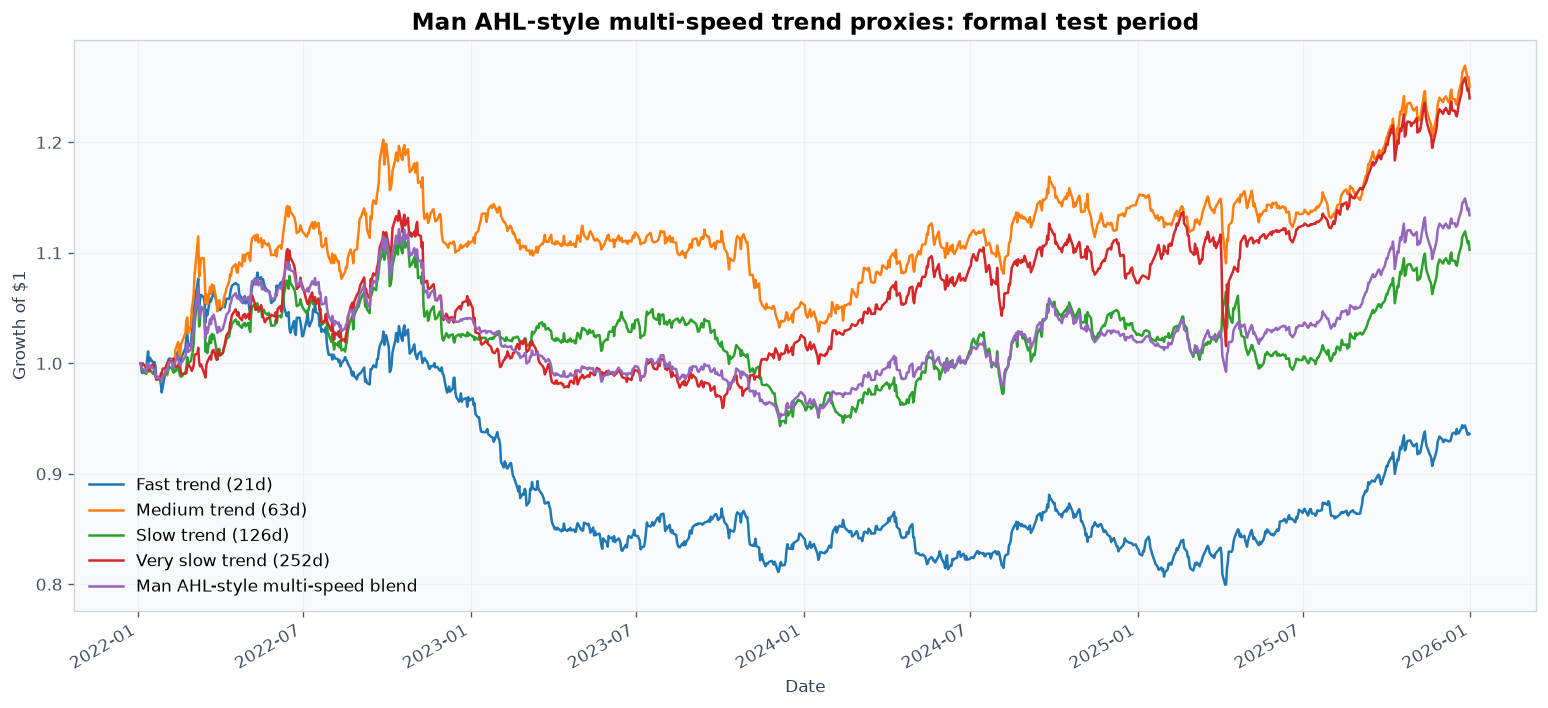

In [4]:
ax = None
for name, result in results.items():
    equity = result.frame['equity'].loc[splits['test'].index]
    ax = (equity / equity.iloc[0]).plot(ax=ax, figsize=(13, 6), label=name)
ax.set_title('Man AHL-style multi-speed trend proxies: formal test period')
ax.set_ylabel('Growth of $1')
ax.grid(alpha=0.25)
ax.legend()
plt.show()

## 🛡️ Crisis and cost diagnostics

Fast systems may respond sooner but trade more. The stress table checks whether any protection arrived before the worst part of each shock; the cost table checks whether turnover changes the story.

In [5]:
stress_windows = {'Global Financial Crisis': ('2007-10-01', '2009-03-31'), 'COVID shock': ('2020-02-19', '2020-03-23'), '2022 inflation/rates shock': ('2022-01-03', '2022-10-14')}
stress_rows = []
for window, (start, end) in stress_windows.items():
    index = close.loc[start:end].index
    for name, result in results.items():
        returns = result.frame.loc[index, 'net_returns']
        equity = (1.0 + returns).cumprod()
        stress_rows.append({'window': window, 'strategy': name, 'return': equity.iloc[-1] - 1.0 if len(equity) else float('nan'), 'max_drawdown': (equity / equity.cummax() - 1.0).min() if len(equity) else float('nan')})
stress_table = pd.DataFrame(stress_rows)
print('Stress-window diagnostics')
display(stress_table.style.format({'return': '{:.2%}', 'max_drawdown': '{:.2%}'}))

cost_rows = []
for cost_bps in [0, 10, 25, 50]:
    for name, target_weights in weights.items():
        result = run_portfolio_backtest(close, target_weights, transaction_cost_bps=cost_bps, benchmark_returns=benchmark_returns)
        metrics = metrics_for_period(result, splits['test'].index)
        cost_rows.append({'strategy': name, 'cost_bps': cost_bps, 'test_return': metrics['total_return_after_costs'], 'test_sharpe': metrics['sharpe_ratio']})
cost_table = pd.DataFrame(cost_rows)
display(cost_table.style.format({'test_return': '{:.2%}', 'test_sharpe': '{:.2f}'}))

Stress-window diagnostics


,window,strategy,return,max_drawdown
0,Global Financial Crisis,Fast trend (21d),7.56%,-9.70%
1,Global Financial Crisis,Medium trend (63d),8.10%,-11.76%
2,Global Financial Crisis,Slow trend (126d),22.52%,-6.74%
3,Global Financial Crisis,Very slow trend (252d),12.79%,-6.92%
4,Global Financial Crisis,Man AHL-style multi-speed blend,12.96%,-6.88%
5,COVID shock,Fast trend (21d),26.65%,-3.85%
6,COVID shock,Medium trend (63d),17.29%,-4.70%
7,COVID shock,Slow trend (126d),-11.01%,-12.33%
8,COVID shock,Very slow trend (252d),-2.20%,-4.54%
9,COVID shock,Man AHL-style multi-speed blend,7.16%,-2.10%


,strategy,cost_bps,test_return,test_sharpe
0,Fast trend (21d),0,-1.94%,-0.01
1,Medium trend (63d),0,27.85%,0.77
2,Slow trend (126d),0,12.74%,0.40
3,Very slow trend (252d),0,25.75%,0.70
4,Man AHL-style multi-speed blend,0,16.06%,0.58
5,Fast trend (21d),10,-6.19%,-0.15
6,Medium trend (63d),10,25.45%,0.71
7,Slow trend (126d),10,10.64%,0.34
8,Very slow trend (252d),10,24.28%,0.67
9,Man AHL-style multi-speed blend,10,13.74%,0.50


In [6]:
best_sharpe = test_table['sharpe_ratio'].idxmax()
highest_turnover = test_table['annualized_turnover'].idxmax()
print('Finding:', best_sharpe, 'had the highest test Sharpe', round(float(test_table.loc[best_sharpe, 'sharpe_ratio']), 2))
print('Finding:', highest_turnover, 'had the highest annualized turnover', round(float(test_table.loc[highest_turnover, 'annualized_turnover']), 2))
print('Read speed, Sharpe, drawdown, and costs together: a faster model can protect sooner while paying more to trade.')

Finding: Medium trend (63d) had the highest test Sharpe 0.71
Finding: Fast trend (21d) had the highest annualized turnover 11.14
Read speed, Sharpe, drawdown, and costs together: a faster model can protect sooner while paying more to trade.


## ⚖️ What went well / what went wrong

**What went well:** Trend following can take long and short positions across several asset classes. Diversification means one market's false signal need not determine the whole portfolio, and faster models can react more quickly to a persistent reversal.

**What went wrong:** Trends do not persist smoothly. Fast models can be whipsawed and incur high turnover; slow models can give back gains before reversing; and sudden V-shaped rebounds can hurt short positions. ETF proxies also omit futures convexity, collateral yield, roll mechanics, leverage, borrow, financing, and execution.

**Beginner takeaway:** “Crisis alpha” is conditional. A trend system often needs a sustained move to help, so it may not protect against a one-week shock or a violent reversal.